# Testing the implementation of biLSTM

In [1]:
from tensorflow.python.client import device_lib
print("\n".join([x.name for x in device_lib.list_local_devices()]))


/device:CPU:0
/device:GPU:0


## Load required libraries

In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Bidirectional, Dense, Dropout, Masking, Input
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from scikeras.wrappers import KerasClassifier
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output
from tqdm import tqdm

# Preprocessing

In [2]:
from sklearn.utils import shuffle

data = np.load("../preprocessing/ready/squat_sequences_normalized.npz")

X_data = data["X"]
y_labels = data["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_labels, test_size=0.3, stratify=y_labels, random_state=42
)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)
print(X_train[0].shape, X_test[0].shape, y_train[0], y_test[0])

# Pick an example (e.g. the first one)
idx = 0
sample = X_train[idx]
label = y_train[idx]

# Show some rows
print(f"\n▶️ Sample index: {idx} — Label: {label}")
print("First 10 frames:")
for i, row in enumerate(sample[:200]):
    print(f"Frame {i}: {row}")

(176, 189, 4) (76, 189, 4) (176,) (76,)
(189, 4) (189, 4) 0 1

▶️ Sample index: 0 — Label: 0
First 10 frames:
Frame 0: [0.9667165  0.94309914 0.9215407  0.08257127]
Frame 1: [0.97353005 0.9424447  0.9262832  0.07479054]
Frame 2: [0.97712755 0.943498   0.93383044 0.07091391]
Frame 3: [0.97584414 0.9460629  0.9418196  0.06956583]
Frame 4: [0.97223926 0.9445299  0.947445   0.07365197]
Frame 5: [0.9690213  0.94246125 0.94896907 0.07148224]
Frame 6: [0.9708965  0.9417224  0.95102805 0.07053024]
Frame 7: [0.9700686  0.9402441  0.94995767 0.06445813]
Frame 8: [0.9700239  0.94050884 0.9481172  0.06097913]
Frame 9: [0.9701104  0.9412055  0.9468388  0.06330073]
Frame 10: [0.97026813 0.93970025 0.9433567  0.06497532]
Frame 11: [0.9680896  0.9362297  0.93315655 0.06662393]
Frame 12: [0.9650458  0.93419635 0.92403466 0.06797868]
Frame 13: [0.9601582  0.9305278  0.9121694  0.06942302]
Frame 14: [0.9555483  0.9293325  0.90375334 0.07678884]
Frame 15: [0.949468   0.9271277  0.8924665  0.08914429]
Fram

# Processing with augmented Data

In [3]:
# Load preprocessed augmented train/test sets
train_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_train.npz")
test_data = np.load("../preprocessing/Augmented_LSTM/squat_sequences_test.npz")

X_train = train_data["X"]
y_train = train_data["y"]
X_test = test_data["X"]
y_test = test_data["y"]

print(f" Loaded: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")
print(f" Input shape: {X_train.shape[1:]} (sequence_len, features)")
print(f" Example label: {y_train[0]}")

# Pick an example (e.g. the first one)
idx = 0
sample = X_train[idx]
label = y_train[idx]

# Show some rows
print(f"\n▶️ Sample index: {idx} — Label: {label}")
print("First 10 frames:")
for i, row in enumerate(sample[:200]):
    print(f"Frame {i}: {row}")

 Loaded: 704 training samples, 76 test samples
 Input shape: (189, 4) (sequence_len, features)
 Example label: 0

▶️ Sample index: 0 — Label: 0
First 10 frames:
Frame 0: [0.96562135 0.94309914 0.9190417  0.07187742]
Frame 1: [0.9726591  0.9424447  0.92393523 0.06387913]
Frame 2: [0.976375   0.943498   0.93172294 0.05989408]
Frame 3: [0.97504926 0.9460629  0.9399666  0.05850834]
Frame 4: [0.97132576 0.9445299  0.94577116 0.06270874]
Frame 5: [0.96800196 0.94246125 0.94734377 0.06047833]
Frame 6: [0.9699389  0.9417224  0.9494683  0.05949974]
Frame 7: [0.96908367 0.9402441  0.94836384 0.05325782]
Frame 8: [0.9690374  0.94050884 0.94646484 0.04968154]
Frame 9: [0.96912694 0.9412055  0.94514567 0.05206805]
Frame 10: [0.9692898  0.93970025 0.9415526  0.0537895 ]
Frame 11: [0.96703947 0.9362297  0.9310276  0.05548418]
Frame 12: [0.9638957  0.93419635 0.92161506 0.05687678]
Frame 13: [0.9588473  0.9305278  0.90937203 0.05836153]
Frame 14: [0.9540856  0.9293325  0.9006879  0.06593335]
Frame 15:

# Defined model Function

In [4]:

def create_bilstm_model(input_shape, lstm_units=64, dropout_rate=0.3, learning_rate=0.001, **kwargs):
    """Creates and compiles a BiLSTM model with given hyperparameters."""
    
    model = Sequential([
        Input(shape=input_shape),
        Masking(mask_value=0.0), # Handles padding (ignores zeros) for the variable-length sequences
        Bidirectional(LSTM(lstm_units, return_sequences=True)), # Extracts temporal patterns from both directions
        Dropout(dropout_rate), # Regularization to prevent overfitting
        Bidirectional(LSTM(lstm_units // 2)),
        Dropout(dropout_rate),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')  # Outputs binary classification (good vs bad)
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

# Random search - Hyperparameter tuning

In [4]:
import random

# Define the simple BiLSTM model
def create_bilstm_model(input_shape, lstm_units=128, dropout_rate=0.2, learning_rate=0.0005):
    model = Sequential([
        Input(shape=input_shape),
        Masking(mask_value=0.0),
        Bidirectional(LSTM(lstm_units)),
        Dropout(dropout_rate),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer=Adam(learning_rate), loss="binary_crossentropy", metrics=["accuracy"])
    return model

# Define random search parameter space
param_space = {
    "lstm_units": lambda: random.randint(50, 150),
    "dropout_rate": lambda: random.uniform(0.2, 0.5),
    "learning_rate": lambda: random.uniform(0.0001, 0.001),
    "batch_size": lambda: random.randint(32, 64),
    "epochs": lambda: random.randint(50, 100)
}

# Run 20 random trials
results = []
for i in range(20):
    params = {k: sampler() for k, sampler in param_space.items()}
    print(f" Trial {i+1} with parameters: {params}")

    model = create_bilstm_model(
        input_shape=(X_train.shape[1], X_train.shape[2]),
        lstm_units=params["lstm_units"],
        dropout_rate=params["dropout_rate"],
        learning_rate=params["learning_rate"]
    )

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=params["epochs"],
        batch_size=params["batch_size"],
        verbose=0
    )

    best_val_accuracy = max(history.history["val_accuracy"])
    results.append({**params, "val_accuracy": best_val_accuracy})
    print(f" Best val accuracy: {best_val_accuracy:.4f}")

# Show sorted results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="val_accuracy", ascending=False)
print("\n🏆 Top 5 Configurations:")
print(results_df.head(5))

 Trial 1 with parameters: {'lstm_units': 102, 'dropout_rate': 0.2724401170357866, 'learning_rate': 0.000499520242696792, 'batch_size': 62, 'epochs': 63}
 Best val accuracy: 0.8298
 Trial 2 with parameters: {'lstm_units': 118, 'dropout_rate': 0.24673489198605517, 'learning_rate': 0.0005721129823824458, 'batch_size': 53, 'epochs': 100}
 Best val accuracy: 0.9149
 Trial 3 with parameters: {'lstm_units': 113, 'dropout_rate': 0.3616009445771142, 'learning_rate': 0.000250309820623621, 'batch_size': 48, 'epochs': 67}
 Best val accuracy: 0.9149
 Trial 4 with parameters: {'lstm_units': 129, 'dropout_rate': 0.3209608558272706, 'learning_rate': 0.00027924341147547027, 'batch_size': 48, 'epochs': 50}
 Best val accuracy: 0.9433
 Trial 5 with parameters: {'lstm_units': 121, 'dropout_rate': 0.31395457585046804, 'learning_rate': 0.00040615035929918815, 'batch_size': 38, 'epochs': 98}
 Best val accuracy: 1.0000
 Trial 6 with parameters: {'lstm_units': 119, 'dropout_rate': 0.3154409994085712, 'learning_

# Train the final model with the best hyperparameters

In [5]:
# Apparently this only outputs the best parameters from the last fold and not the best parameters overall (most common over all folds) 
# print(f"\n Best overall parameters: {grid_search.best_params_}")


best_config = {
    "lstm_units": 121,
    "dropout_rate": 0.313955,
    "learning_rate": 0.000406,
    "epochs": 98,
    "batch_size": 38
}

final_model = create_bilstm_model(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    lstm_units=best_config["lstm_units"],
    dropout_rate=best_config["dropout_rate"],
    learning_rate=best_config["learning_rate"]
)

final_model.fit(
    X_train, y_train,
    epochs=best_config["epochs"],
    batch_size=best_config["batch_size"],
    verbose=1
)

loss, accuracy = final_model.evaluate(X_test, y_test, verbose=0)
print(f"✅ Final test accuracy: {accuracy:.4f}")

# Save
# model.save("test_bilstm_model.h5")

Epoch 1/98
19/19 [==============================] - 20s 81ms/step - loss: 0.6955 - accuracy: 0.4915
Epoch 2/98
19/19 [==============================] - 1s 78ms/step - loss: 0.6935 - accuracy: 0.4957
Epoch 3/98
19/19 [==============================] - 1s 77ms/step - loss: 0.6938 - accuracy: 0.5085
Epoch 4/98
19/19 [==============================] - 1s 78ms/step - loss: 0.6906 - accuracy: 0.5227
Epoch 5/98
19/19 [==============================] - 2s 82ms/step - loss: 0.6922 - accuracy: 0.5085
Epoch 6/98
19/19 [==============================] - 1s 78ms/step - loss: 0.6632 - accuracy: 0.6136
Epoch 7/98
19/19 [==============================] - 1s 79ms/step - loss: 0.6579 - accuracy: 0.6037
Epoch 8/98
19/19 [==============================] - 1s 78ms/step - loss: 0.5867 - accuracy: 0.6932
Epoch 9/98
19/19 [==============================] - 1s 77ms/step - loss: 0.6107 - accuracy: 0.6491
Epoch 10/98
19/19 [==============================] - 1s 78ms/step - loss: 0.5797 - accuracy: 0.7060
Epoch 11

# Evaluation

In [6]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Predict probabilities
y_pred_probs = final_model.predict(X_test).flatten()

# Convert to binary predictions using threshold = 0.5
y_pred = (y_pred_probs > 0.5).astype("int")

# Print classification report
print(" Classification Report:")
print(classification_report(y_test, y_pred))

# Print confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:")
print(cm)

# Print ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")

3/3 [==============================] - 6s 29ms/step
 Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        39
           1       0.95      0.97      0.96        37

    accuracy                           0.96        76
   macro avg       0.96      0.96      0.96        76
weighted avg       0.96      0.96      0.96        76


 Confusion Matrix:
[[37  2]
 [ 1 36]]

 ROC-AUC Score: 0.9875


Original test accuracy: 0.8684
Feature 'valgus_angle_left' caused accuracy drop: 0.0000
Feature 'valgus_angle_right' caused accuracy drop: 0.0395
Feature 'torso_angle' caused accuracy drop: 0.3553
Feature 'squat_depth' caused accuracy drop: 0.3553


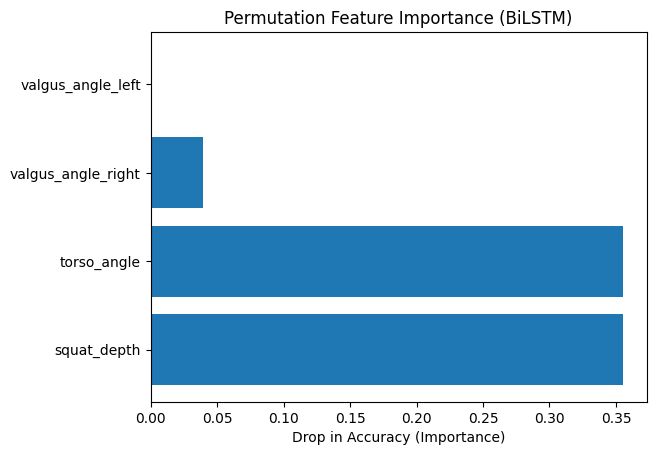

In [17]:

# Copy the original test set
X_test_copy = X_test.copy()
original_accuracy = final_model.evaluate(X_test_copy, y_test, verbose=0)[1]
print(f"Original test accuracy: {original_accuracy:.4f}")

# Feature names
feature_names = ["valgus_angle_left", "valgus_angle_right", "torso_angle", "squat_depth"]

# Permutation importance
importances = []

for i in range(X_test.shape[2]):  # loop over features
    X_permuted = X_test_copy.copy()
    for seq in X_permuted:
        np.random.shuffle(seq[:, i])  # shuffle the i-th feature across time in each sequence

    permuted_acc = final_model.evaluate(X_permuted, y_test, verbose=0)[1]
    drop = original_accuracy - permuted_acc
    importances.append(drop)
    print(f"Feature '{feature_names[i]}' caused accuracy drop: {drop:.4f}")

# Plot
import matplotlib.pyplot as plt

plt.barh(feature_names, importances)
plt.xlabel("Drop in Accuracy (Importance)")
plt.title("Permutation Feature Importance (BiLSTM)")
plt.gca().invert_yaxis()
plt.show()
